In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

import joblib
import warnings

warnings.filterwarnings("ignore")

In [2]:

df = pd.read_csv("../data/customer_churn.csv")

print("Original shape:", df.shape)

Original shape: (5000, 21)


In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Remove CustomerID
df = df.drop(columns=["CustomerID"])

In [4]:
# Average monthly spending
df["AverageMonthlySpend"] = (
    df["TotalCharges"]
    / df["Tenure"].replace(0, np.nan)
)

df["AverageMonthlySpend"] = (
    df["AverageMonthlySpend"]
    .fillna(df["MonthlyCharges"])
)


# Difference between current and historical average charge
df["ChargeDifference"] = (
    df["MonthlyCharges"]
    - df["AverageMonthlySpend"]
)


# Number of subscribed services
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = 0

for column in service_columns:
    df["ServiceCount"] += (
        df[column] == "Yes"
    ).astype(int)


# Tenure group
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "New",
        "Developing",
        "Established",
        "Loyal"
    ]
)


# Charge group
df["ChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


# Contract risk
df["ContractRisk"] = df["Contract"].map({
    "Month-to-month": 2,
    "One year": 1,
    "Two year": 0
})


# Electronic payment
df["ElectronicPayment"] = (
    df["PaymentMethod"] == "Electronic check"
).astype(int)


# Technical support
df["HasTechSupport"] = (
    df["TechSupport"] == "Yes"
).astype(int)


# Online security
df["HasOnlineSecurity"] = (
    df["OnlineSecurity"] == "Yes"
).astype(int)

In [5]:
print("Final shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget:")
print(df["Churn"].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Final shape: (5000, 29)

Missing values:
Gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
Tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
AverageMonthlySpend    0
ChargeDifference       0
ServiceCount           0
TenureGroup            0
ChargeGroup            0
ContractRisk           0
ElectronicPayment      0
HasTechSupport         0
HasOnlineSecurity      0
dtype: int64

Target:
Churn
No     4350
Yes     650
Name: count, dtype: int64

Columns:
['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup

In [6]:
df.to_csv(
    "../data/customer_churn_featured.csv",
    index=False
)

print("Featured dataset saved successfully.")

Featured dataset saved successfully.


In [7]:
df = pd.read_csv(
    "../data/customer_churn_featured.csv"
)

print(df.shape)

(5000, 29)


In [8]:


X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 28)
y shape: (5000,)


In [9]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True) * 100)

Churn
No     4350
Yes     650
Name: count, dtype: int64

Churn
No     87.0
Yes    13.0
Name: proportion, dtype: float64


In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 28)
X_test : (1000, 28)
y_train: (4000,)
y_test : (1000,)


In [11]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Churn
No     87.0
Yes    13.0
Name: proportion, dtype: float64

Testing distribution:
Churn
No     87.0
Yes    13.0
Name: proportion, dtype: float64


In [12]:

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlySpend', 'ChargeDifference', 'ServiceCount', 'ContractRisk', 'ElectronicPayment', 'HasTechSupport', 'HasOnlineSecurity']

Categorical features:
['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup', 'ChargeGroup']


In [13]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [14]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [15]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (4000, 60)
Processed testing shape: (1000, 60)


In [16]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Total encoded features:",
    len(feature_names)
)

Total encoded features: 60


In [17]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print(X_train_processed_df.shape)

(4000, 60)


In [18]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

In [19]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

selector.fit(
    X_train_processed_df,
    y_train
)

SelectKBest(k='all',
            score_func=<function mutual_info_classif at 0x000002E5B7DE0A90>)

In [20]:
feature_scores = pd.DataFrame({
    "Feature": feature_names,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores.head(20)

,Feature,Score
1,num__Tenure,0.046376
7,num__ContractRisk,0.034504
43,cat__Contract_Month-to-month,0.031727
54,cat__TenureGroup_Loyal,0.026597
45,cat__Contract_Two year,0.020505
55,cat__TenureGroup_New,0.020214
5,num__ChargeDifference,0.019396
3,num__TotalCharges,0.018543
23,cat__InternetService_Fiber optic,0.017032
56,cat__ChargeGroup_High,0.013985


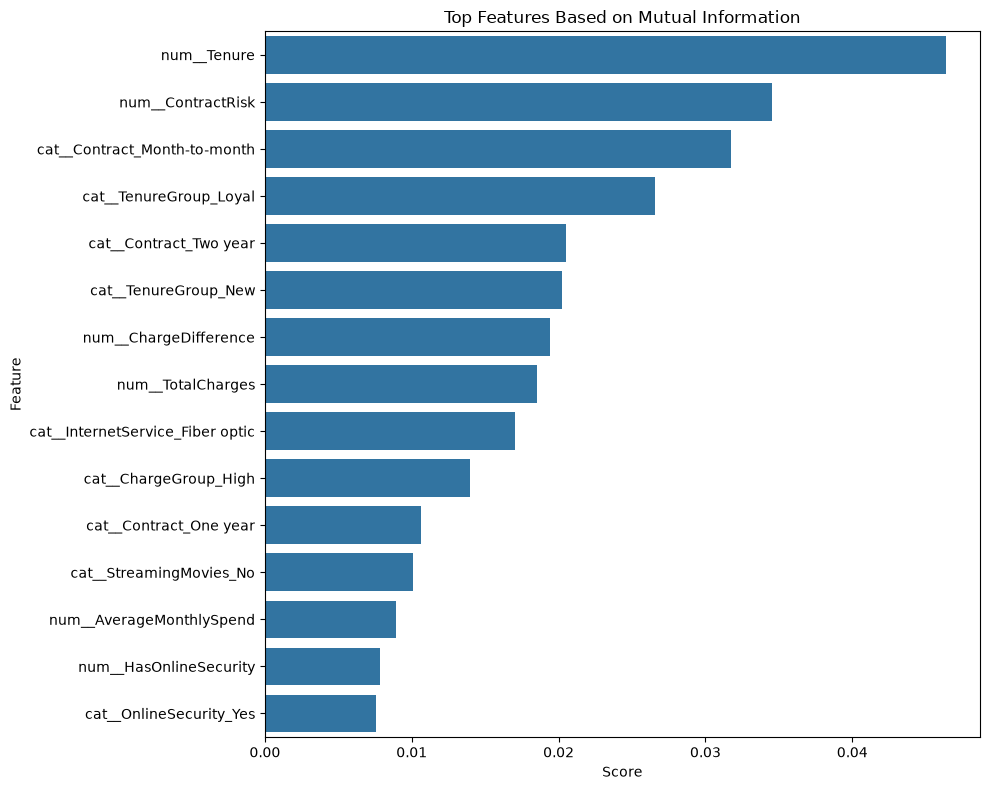

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

top_features = feature_scores.head(15)

sns.barplot(
    data=top_features,
    x="Score",
    y="Feature"
)

plt.title(
    "Top Features Based on Mutual Information"
)

plt.tight_layout()
plt.show()

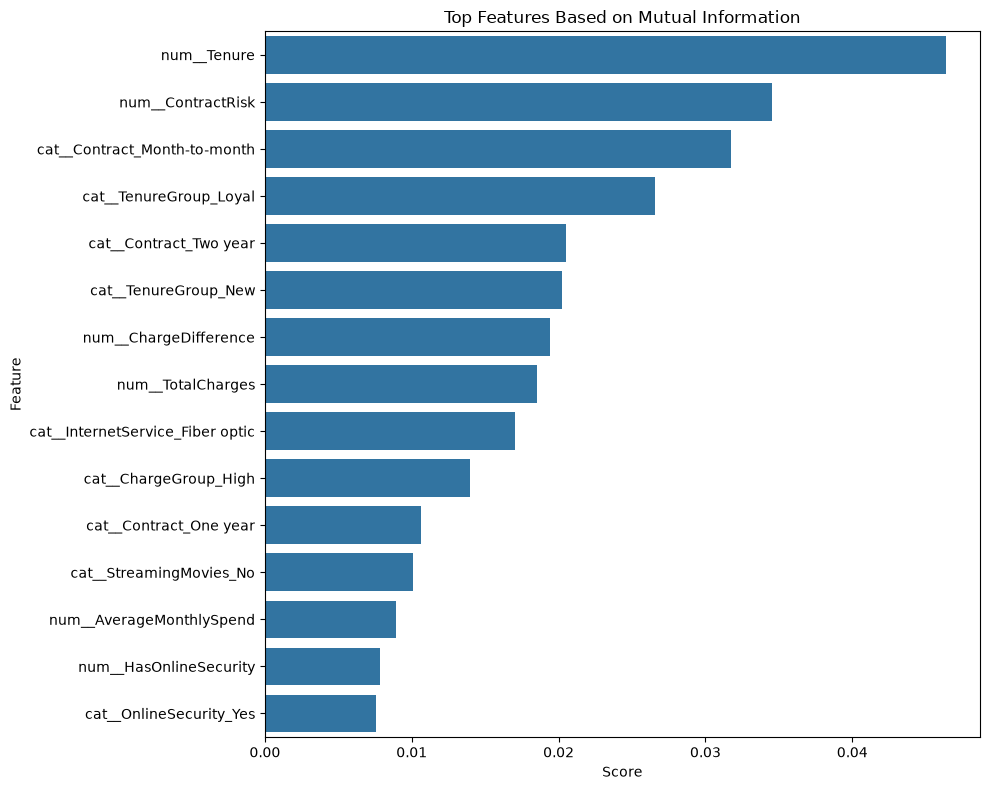

In [22]:
plt.figure(figsize=(10, 8))

top_features = feature_scores.head(15)

sns.barplot(
    data=top_features,
    x="Score",
    y="Feature"
)

plt.title("Top Features Based on Mutual Information")

plt.tight_layout()
plt.show()

In [23]:
feature_scores.head(20)

,Feature,Score
1,num__Tenure,0.046376
7,num__ContractRisk,0.034504
43,cat__Contract_Month-to-month,0.031727
54,cat__TenureGroup_Loyal,0.026597
45,cat__Contract_Two year,0.020505
55,cat__TenureGroup_New,0.020214
5,num__ChargeDifference,0.019396
3,num__TotalCharges,0.018543
23,cat__InternetService_Fiber optic,0.017032
56,cat__ChargeGroup_High,0.013985


In [24]:
k = 15

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_processed_df,
    y_train
)

X_test_selected = selector.transform(
    X_test_processed_df
)

print("Selected training shape:", X_train_selected.shape)
print("Selected testing shape:", X_test_selected.shape)

Selected training shape: (4000, 15)
Selected testing shape: (1000, 15)


In [25]:
selected_features = feature_names[
    selector.get_support()
]

print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
num__Tenure
num__TotalCharges
num__ChargeDifference
num__ContractRisk
cat__Dependents_No
cat__InternetService_Fiber optic
cat__TechSupport_No
cat__TechSupport_No internet service
cat__StreamingMovies_No internet service
cat__Contract_Month-to-month
cat__Contract_Two year
cat__PaymentMethod_Credit card
cat__TenureGroup_Developing
cat__TenureGroup_Loyal
cat__TenureGroup_New


In [26]:
import os

os.makedirs("../models", exist_ok=True)

In [27]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [28]:
joblib.dump(
    selector,
    "../models/feature_selector.pkl"
)

['../models/feature_selector.pkl']

In [29]:
joblib.dump(
    selected_features.tolist(),
    "../models/selected_features.pkl"
)

['../models/selected_features.pkl']

In [30]:
print("Preprocessor saved.")
print("Feature selector saved.")
print("Selected features saved.")

Preprocessor saved.
Feature selector saved.
Selected features saved.


In [31]:
joblib.dump(
    X_train,
    "../models/X_train.pkl"
)

joblib.dump(
    X_test,
    "../models/X_test.pkl"
)

joblib.dump(
    y_train,
    "../models/y_train.pkl"
)

joblib.dump(
    y_test,
    "../models/y_test.pkl"
)

['../models/y_test.pkl']